In [ ]:
import sys
import os
import pandas as pd
notebook_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))  # Add the project root directory to the path
import custom_io as cio
import env_reader
import matplotlib.pyplot as plt
import h5py
import numpy as np

In [2]:
er = env_reader.read_env()
output_dir = er["OUTPUT_FOLDER"]

In [3]:
def map_window_type(win_type: str):
    """
    Convert the window type to a standard naming convention

    Args:
        win_type (str): _description_

    Returns:
        _type_: _description_
    """
    if "ca1" in win_type.lower():
        return "CA1"
    if "cx" in win_type.lower() or "ctx" in win_type.lower() or "nc" in win_type.lower():
        return "CTX"

In [4]:
fpath_assembled_traces = cio.open_file("Open assembled traces h5 file")
print(fpath_assembled_traces)

D:\sciebo\Test\Locomotion_analysis\TMEV\assembled_traces_tmev.h5


In [7]:
is_tmev = "tmev" in fpath_assembled_traces.lower()

In [12]:
dict_traces = dict()
with h5py.File(fpath_assembled_traces, "r") as f:
    for uuid in f.keys():
        # for win stim, only take sz + sd
        if "chr2" in f[uuid].attrs['exp_type'].lower():
            is_tmev = False
            if "sz" not in f[uuid].attrs['exp_type'].lower():
                continue
        has_lfp = f[uuid].attrs['has_lfp']
        n_recordings = len(f[uuid].attrs["recording_break_points"][()])
        if n_recordings > 1:  # each recording should have its own lfp
            has_lfp = has_lfp.all()
        segment_type_break_points_lfp = None if not has_lfp else f[uuid].attrs['segment_type_break_points_lfp'][()] 
        dict_traces[uuid] = {
            'mouse_id': f[uuid].attrs['mouse_id'],
            'window_type': map_window_type(f[uuid].attrs['window_type']),
            'has_lfp': has_lfp,
            'lfp_t': f[uuid]['lfp_t'][()],
            'lfp_y': f[uuid]['lfp_y'][()],
            'lfp_mov_y': f[uuid]['lfp_mov_y'][()],
            'lv_speed': f[uuid]['lv_speed'][()],
            'lv_t_s': f[uuid]['lv_t_s'][()],
            'mean_fluo': f[uuid]['mean_fluo'][()],
            'segment_type_break_points': f[uuid].attrs['segment_type_break_points'],
            'segment_type_break_points_lfp': segment_type_break_points_lfp,
            'recording_break_points': f[uuid].attrs["recording_break_points"],
        }
        if not is_tmev:
            dict_traces[uuid]["i_stim_begin_frame"] = f[uuid].attrs["i_stim_begin_frame"]
            dict_traces[uuid]["i_stim_end_frame"] = f[uuid].attrs["i_stim_end_frame"]
uuids_list = list(dict_traces.keys())

In [ ]:
dict_begin_end_frames = {
    "2251bba132cf45fa839d3214d1651392": (5000,5151),
"30bcfb76a771468eab5c2a0bb71038d7": (4998,5021),
"39f7ef9f661041428bdd57a5b15c7176": (5000,5005),
"4dea78a01bf5408092f498032d67d84e": (4998,5000),
"4e2310d2dde845b0908519b7196080e8": (5020,5055),
"54c31c3151944cfd86043932d3a19b9a": (4998,5095),
"58dbee01eacf4b7385e0192c812233da": (5000,5030),
"5cfb012d47f14303a40680d2b333336a": (5000,5030),
"5ecdd9dc8f13440f9becae3cde5ab574": (5000,5030),
"74473c5d22e04525acf53f5a5cb799f4": (5000,5030),
"7753b03a2a554cccaab42f1c0458d742": (5000,5030),
"7b9c17d8a1b0416daf65621680848b6a": (5000,5030),
"9e75d7135137444492d104c461ddcaac": (5000,5030),
"a39ed3a880c54f798eff250911f1c92f": (5000,5030),
"aa66ae0470a14eb08e9bcadedc34ef64": (5000,5030),
"c7b29d28248e493eab02288b85e3adee": (5000,5030),
"cd3c1e0e3c284a89891d2e4d9a7461f4": (5000,5030),
"d158cd12ad77489a827dab1173a933f9": (5000,5030),
"f0442bebcd1a4291a8d0559eb47df08e": (5000,5030),
"f481149fa8694621be6116cb84ae2d3c": (5000,5030),
"f5ccb81a34bb434482e2498bfdf88784": (5000,5030)
}
# TODO exclude: f0442bebcd1a4291a8d0559eb47df08e, 

In [66]:
def plot_sz_begins():
    fig, axs = plt.subplots(len(uuids_list), 1, figsize=(10, 6*len(uuids_list)))
    n_frames_before = 50
    n_frames_after = 300
    for i_sz, uuid in enumerate(uuids_list):
        idx_begin = dict_traces[uuid]["segment_type_break_points"][1]  # indices are beginning of bl, beginning of sz, beginning of post
        #fluo_x = dict_traces[uuid]['lv_t_s'][idx_begin-n_frames_before:idx_begin+n_frames_after]
        fluo_y = dict_traces[uuid]['mean_fluo'][idx_begin-n_frames_before:idx_begin+n_frames_after]
        axs[i_sz].plot(fluo_y, linewidth=0.5, color="green", label="mean fluo")
        axs[i_sz].vlines(dict_begin_end_frames[uuid][0] - idx_begin + n_frames_before, ymin=min(fluo_y)-1, ymax=max(fluo_y)+1, color="red", linewidth=0.5, label="sz begin")
        axs[i_sz].vlines(dict_begin_end_frames[uuid][1] - idx_begin + n_frames_before, ymin=min(fluo_y)-1, ymax=max(fluo_y)+1, color="blue", linewidth=0.5, label="sz end")
        axs[i_sz].set_xlabel("frames")
        axs[i_sz].set_title(f"{uuid} - {dict_traces[uuid]['mouse_id']} - {dict_traces[uuid]['window_type']}")
        axs[i_sz].legend()
    plt.show()

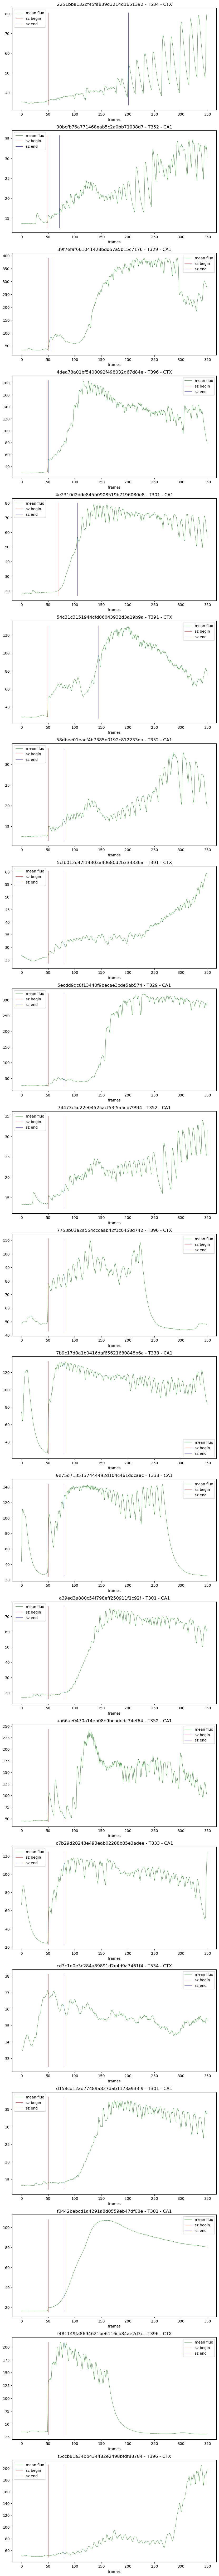

In [107]:
plot_sz_begins()